In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [74]:
df = pd.read_csv("Ecommerce_Sales_Dataset.csv")
df.head()

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01/01/2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02/01/2023,Toys,569.48,3.60,Premium,6807.56,16
2,03/01/2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04/01/2023,Toys,923.27,0.61,Premium,9422.75,29
4,05/01/2023,Toys,710.17,47.83,Premium,1756.83,17


In [75]:
features = df[['Price', 'Discount', 'Marketing_Spend']].values
target_value = df['Units_Sold'].values
num_genes = 4
gene_bounds = (-5, 0)
W1 = np.hstack((np.ones((features.shape[0], 1)), features))

In [76]:
pop_size = 50
n_gen = 100
elite_count = 5
crossover_p = 0.8
mutate_p = 0.2

In [77]:
pop = np.random.uniform(
    low=gene_bounds[0],
    high=gene_bounds[1] + 1,
    size=(pop_size, num_genes)
)

In [78]:
def total_value(individual):
    return np.dot(features, individual[1:])

def fitness(individual):
    predictions = total_value(individual)
    return mean_absolute_error(target_value, predictions)

In [79]:
best_history = []

for gen in range(n_gen):
    fitness_vals = np.array([fitness(ind) for ind in pop])

    best_idx = np.argmin(fitness_vals)
    best_fit = fitness_vals[best_idx]
    best_ind = pop[best_idx]
    best_history.append((gen, best_fit, best_ind.copy()))

    elite_indices = np.argsort(fitness_vals)[-elite_count:]
    elites = pop[elite_indices].copy()

    min_f = fitness_vals.min()
    weights = fitness_vals - min_f + 1e-6
    probs = weights / weights.sum()

    selected_indices = np.random.choice(
        np.arange(pop_size),
        size=(pop_size - elite_count),
        replace=True,
        p=probs
    )
    selected = pop[selected_indices].copy()

    new_pop = np.vstack([elites, selected])

    for i in range(elite_count, pop_size - 1, 2):
        if np.random.rand() < crossover_p:
            cp = np.random.randint(1, num_genes)
            a, b = new_pop[i].copy(), new_pop[i+1].copy()
            a[cp:], b[cp:] = b[cp:].copy(), a[cp:].copy()
            new_pop[i], new_pop[i+1] = a, b


    for i in range(elite_count, pop_size):
        for j in range(num_genes):
            if np.random.rand() < mutate_p:
                delta = np.random.choice([-1, 1])
                new_val = np.clip(new_pop[i][j] + delta, *gene_bounds)
                new_pop[i][j] = new_val

    pop = new_pop

In [80]:
print("\n--- Evolution Trace ---")
for gen, fit, ind in best_history[:5]:
    print(f"Gen {gen:02d}: Individual = {ind}, Value = {total_value(ind)}, Fitness = {fit}")

print("\n... (skipping mid generations) ...\n")

for gen, fit, ind in best_history[-5:]:
    print(f"Gen {gen:02d}: Individual = {ind}, Value = {total_value(ind)}, Fitness = {fit}")


--- Evolution Trace ---
Gen 00: Individual = [-3.08515258  0.34697594 -3.81149076 -0.03413879], Value = [-4.43423885e+01 -4.85273452e+01  9.96837337e+01 -3.65378338e+00
  4.13225346e+00 -2.57223587e+02 -1.02795627e+02 -8.36710427e+01
 -1.40138606e+02  1.23699181e+01  1.42175635e+02  6.77676853e+01
 -8.08249244e+01 -4.04146929e+01 -2.58202455e+01 -1.12885096e+01
 -2.33308313e+02  2.93593411e+01  2.25842586e+02 -1.26282921e+01
 -1.16450557e+02 -2.15536802e+02 -3.36627322e+02 -2.40874058e+02
 -3.46720989e+01 -3.46253275e+02 -1.83722091e+02 -1.75887637e+02
 -7.39032898e+01  1.63008723e+02 -8.25034327e+01 -1.58940097e+02
 -2.10215339e+02 -9.75065713e+01 -3.09918229e+02 -7.91695746e+01
 -8.01198278e+01 -9.26333908e+01 -1.26537877e+02 -9.71343826e+00
  8.48201287e+01 -2.37657732e+02 -2.75764812e+02 -4.83012598e+01
 -1.37770184e+02 -1.46014350e+02 -3.22001290e+02  1.46903634e+02
 -3.77818881e+02 -2.05703227e-01 -2.65070090e+02 -3.21701398e+01
 -6.62580428e+00 -2.21785374e+02 -2.41838608e+02 -

In [81]:
best_gen, best_fit, best_ind = min(best_history, key=lambda x: x[1])

print(f"\nBest found in Generation {best_gen}")
print(f"   Individual: {best_ind}")
print(f"   Total Value: {total_value(best_ind)}")
print(f"   Fitness: {best_fit}")


Best found in Generation 0
   Individual: [-3.08515258  0.34697594 -3.81149076 -0.03413879]
   Total Value: [-4.43423885e+01 -4.85273452e+01  9.96837337e+01 -3.65378338e+00
  4.13225346e+00 -2.57223587e+02 -1.02795627e+02 -8.36710427e+01
 -1.40138606e+02  1.23699181e+01  1.42175635e+02  6.77676853e+01
 -8.08249244e+01 -4.04146929e+01 -2.58202455e+01 -1.12885096e+01
 -2.33308313e+02  2.93593411e+01  2.25842586e+02 -1.26282921e+01
 -1.16450557e+02 -2.15536802e+02 -3.36627322e+02 -2.40874058e+02
 -3.46720989e+01 -3.46253275e+02 -1.83722091e+02 -1.75887637e+02
 -7.39032898e+01  1.63008723e+02 -8.25034327e+01 -1.58940097e+02
 -2.10215339e+02 -9.75065713e+01 -3.09918229e+02 -7.91695746e+01
 -8.01198278e+01 -9.26333908e+01 -1.26537877e+02 -9.71343826e+00
  8.48201287e+01 -2.37657732e+02 -2.75764812e+02 -4.83012598e+01
 -1.37770184e+02 -1.46014350e+02 -3.22001290e+02  1.46903634e+02
 -3.77818881e+02 -2.05703227e-01 -2.65070090e+02 -3.21701398e+01
 -6.62580428e+00 -2.21785374e+02 -2.41838608e+

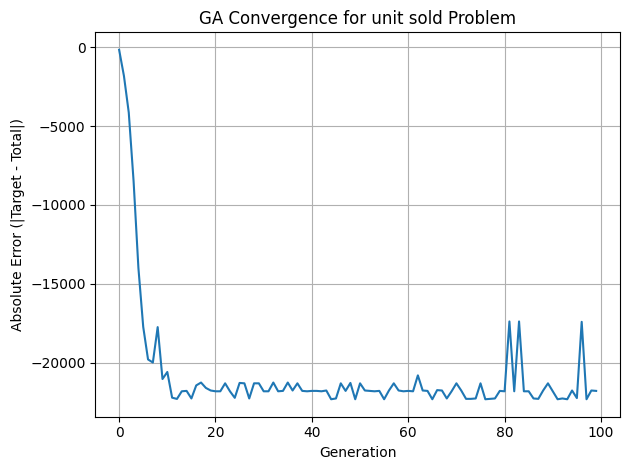

In [82]:
plt.plot([gen for gen, _, _ in best_history], [-fit for _, fit, _ in best_history])
plt.xlabel("Generation")
plt.ylabel("Absolute Error (|Target - Total|)")
plt.title("GA Convergence for unit sold Problem")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
features = df[['Price', 'Discount', 'Marketing_Spend']].values
target_value = df['Units_Sold'].values
n = len(target_value)
bounds = [(-5, 0)] * 4 + [(0, None)] * n
c = [0, 0, 0, 0] + [1] * n

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [ ]:
A = []
b = []
for i in range(n):
  x1, x2, x3 = features_scaled[i]
  y = target_value[i]
  con1 = [-1, -x1, -x2, -x3] + [0] * n
  con1[4 + i] = -1
  A.append(con1)
  b.append(-y)
  con2 = [1, x1, x2, x3] + [0] * n
  con2[4 + i] = -1
  A.append(con2)
  b.append(y)

result = linprog(c=c, A_ub=A, b_ub=b, bounds=bounds, method='highs')
res = dict(result)
W1, W2, W3, W4 = result.x[:4]
y_pred = W1 + W2 * features_scaled[:, 0] + W3 * features_scaled[:, 1] + W4 * features_scaled[:, 2]
mae = np.mean(np.abs(target_value - y_pred))

In [91]:
print("Optimal weights from linear programming:")
print(f"W1 = {W1}")
print(f"W2 = {W2}")
print(f"W3 = {W3}")
print(f"W4 = {W4}")
print(f"Final MAE = {mae}")

Optimal weights from linear programming:
W1 = 0.0
W2 = 0.0
W3 = 0.0
W4 = 0.0
Final MAE = 29.631


In [92]:
print("Optimal weights from genetic algorithm:")
print(f"W1 = {best_ind[0]}")
print(f"W2 = {best_ind[1]}")
print(f"W3 = {best_ind[2]}")
print(f"W4 = {best_ind[3]}")
print(f"Final MAE = {best_fit}")

Optimal weights from genetic algorithm:
W1 = -3.0851525764403958
W2 = 0.3469759354145774
W3 = -3.8114907623392233
W4 = -0.03413878601319276
Final MAE = 155.51810607591878


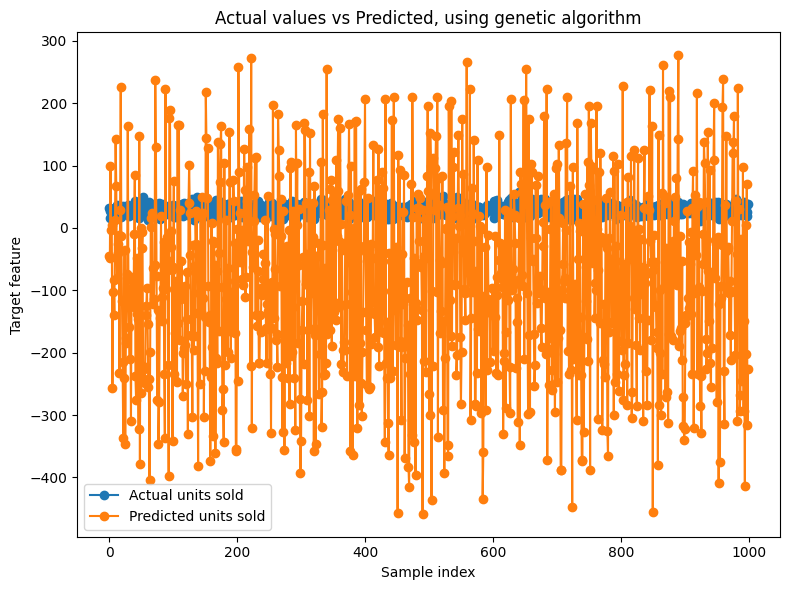

In [87]:
plt.figure(figsize=(8, 6))
plt.plot(target_value, label='Actual units sold', marker = 'o')
plt.plot(total_value(best_ind), label='Predicted units sold', marker = 'o')
plt.title('Actual values vs Predicted, using genetic algorithm')
plt.xlabel('Sample index')
plt.ylabel('Target feature')
plt.legend()
plt.tight_layout()
plt.show()

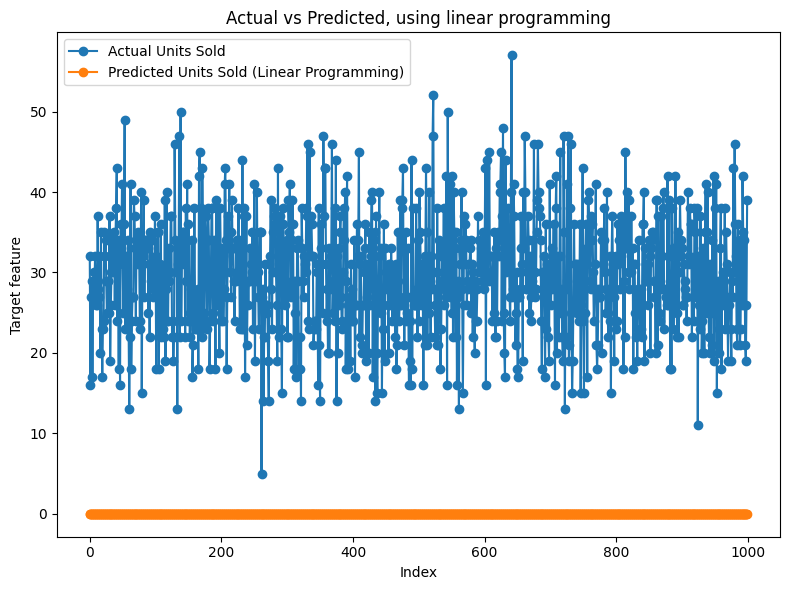

In [88]:
plt.figure(figsize=(8, 6))
plt.plot(target_value, label='Actual Units Sold', marker='o')
plt.plot(y_pred, label='Predicted Units Sold (Linear Programming)', marker='o')
plt.title('Actual vs Predicted, using linear programming')
plt.xlabel('Index')
plt.ylabel('Target feature')
plt.legend()
plt.tight_layout()
plt.show()

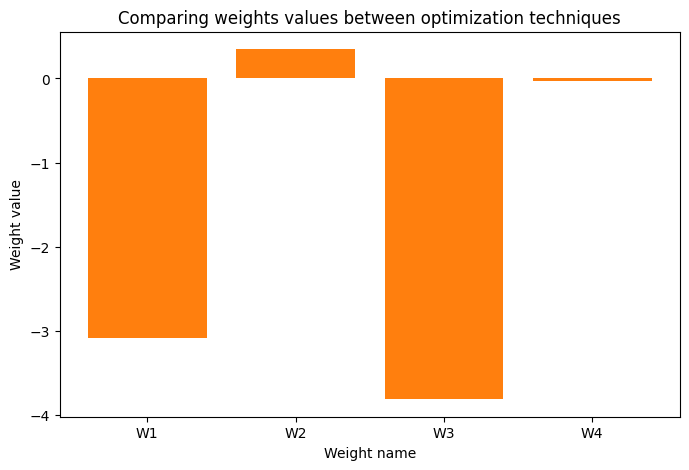

In [94]:
weight_names = ['W1', 'W2', 'W3', 'W4']
lin_weights = [W1, W2, W3, W4]
for w in lin_weights:
 float(w)
lin_weights

plt.figure(figsize=(8, 5))
plt.bar(weight_names, lin_weights)
plt.bar(weight_names, best_ind)
plt.title('Comparing weights values between optimization techniques')
plt.xlabel('Weight name')
plt.ylabel('Weight value')
plt.show()

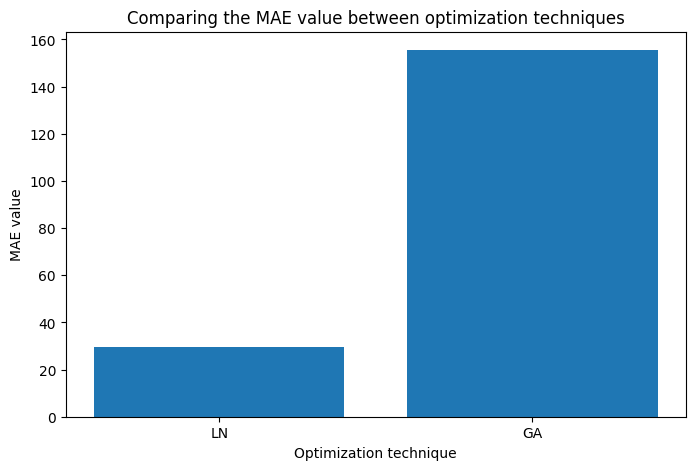

In [95]:
plt.figure(figsize=(8, 5))
plt.bar(['LN', 'GA'], [mae,best_fit])
plt.title('Comparing the MAE value between optimization techniques')
plt.xlabel('Optimization technique')
plt.ylabel('MAE value')
plt.show()